In [2]:
from config import *
from Image_charge_3d import *

In [14]:
### consider charge trap at a distance R_CT

R_CT = np.linspace(-100,100,201)

E_med1_a = np.empty((R_CT.shape[0],3))
E_med1_bX = np.empty((R_CT.shape[0],3))
E_med1_bZ = np.empty((R_CT.shape[0],3))
E_med1_bY = np.empty((R_CT.shape[0],3))

T_OX = 5 ### IN NM
T_SIGE = 60 ### IN NM
T_QW = 9   ### IN NM  ##irrelevnt

EP_QW = 11.7
EP_SIGE = 13.1
EP_OX = 3.9 ## SiO2 

# EP_QW = 11
# EP_SIGE = 11
# EP_OX = 11 ## SiO2 

## Dot location where e field and potential needs to be calculated 
Z = 67       ### in qw
Y = 0
X = 0


## charge trap location 
#X_CT = loops over RCT  ## in nm
Y_CT = 0  ## in nm
Z_CT = 5 ## in nm  ### at the oxide interface

In [15]:
for i in range(R_CT.shape[0]):
    ### Assume that R is in X direction , Y is zero. direction doesn't matter

    #heta = Charge_in_medium3(ee, Z_CT, Y_CT, X_CT, EP_QW, EP_SIGE, EP_OX, T_SIGE, T_OX, 1e-6)
    heta = Charge_in_medium3(-ee, Z_CT, Y_CT, R_CT[i], EP_QW, EP_SIGE, EP_OX, T_SIGE, T_OX, 1e-6)
    img_chrgs = heta.calc_image_charges() 
    E_med1_a[i,:] = heta.calc_ele_medium1(X, Y, Z)               ### qw


    hetbz = Charge_in_medium3(-ee, Z_CT+0.1, Y_CT, R_CT[i], EP_QW, EP_SIGE, EP_OX, T_SIGE, T_OX, 1e-6)
    img_chrgs = hetbz.calc_image_charges() 
    E_med1_bZ[i,:] = hetbz.calc_ele_medium1(X, Y, Z)               ### qw 


    hetby = Charge_in_medium3(-ee, Z_CT, Y_CT+0.1, R_CT[i], EP_QW, EP_SIGE, EP_OX, T_SIGE, T_OX, 1e-6)
    img_chrgs = hetby.calc_image_charges() 
    E_med1_bY[i,:] = hetby.calc_ele_medium1(X, Y, Z)

    hetbx = Charge_in_medium3(-ee, Z_CT, Y_CT, R_CT[i]+0.1, EP_QW, EP_SIGE, EP_OX, T_SIGE, T_OX, 1e-6)
    img_chrgs = hetbx.calc_image_charges() 
    E_med1_bX[i,:] = hetbx.calc_ele_medium1(X, Y, Z)

    if i%1000 ==0:
        print(i)
        print(img_chrgs)
    #print(V_in_medium1_b, "in mV", E_med1_b , "in mV/nm")
    #print(V_in_medium2, "in mV", E_med2 , "in mV/nm")

0
2952


In [16]:
bool1 = np.all(E_med1_bX -E_med1_a == E_med1_bY-E_med1_a)
bool2 = np.all(E_med1_bY -E_med1_a== E_med1_bZ-E_med1_a)
bool3 = np.all(E_med1_bX -E_med1_a == E_med1_bZ-E_med1_a) 
print(bool1, bool2, bool3)

False False False


In [17]:
bool1 = np.all(E_med1_bX == E_med1_bY)
bool2 = np.all(E_med1_bY == E_med1_bZ)
bool3 = np.all(E_med1_bX == E_med1_bZ) 
print(bool1, bool2, bool3)

False False False


(-2.0, 2.0)

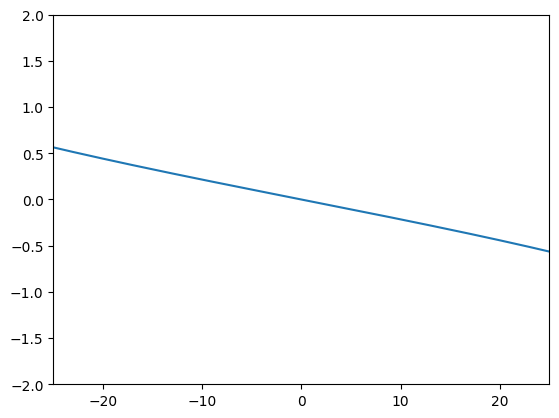

In [35]:
ratio = (E_med1_bZ[:,2] - E_med1_a[:,2])/(E_med1_bZ[:,0] - E_med1_a[:,0])

plt.plot(R_CT,ratio)
plt.xlim(xmin=-25,xmax=25)
plt.ylim(ymin=-2, ymax=+2)

(-2.0, 2.0)

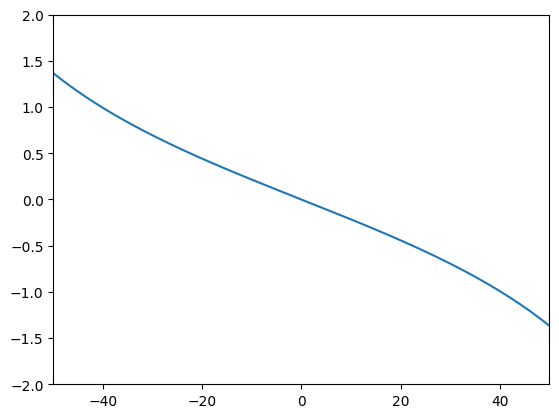

In [34]:
ratio = (E_med1_bZ[:,2] - E_med1_a[:,2])/(E_med1_bZ[:,0] - E_med1_a[:,0])

plt.plot(R_CT,ratio)
plt.xlim(xmin=-50,xmax=50)
plt.ylim(ymin=-2, ymax=+2)

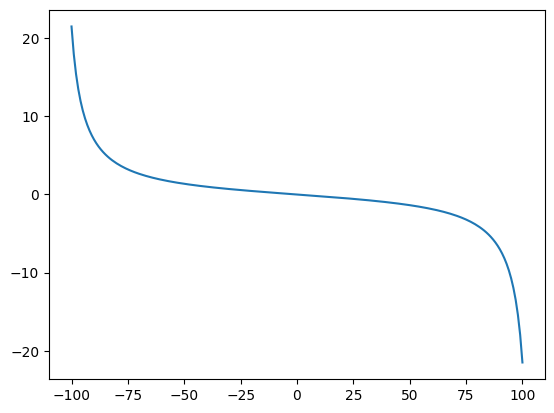

In [30]:
ratio = (E_med1_bZ[:,2] - E_med1_a[:,2])/(E_med1_bZ[:,0] - E_med1_a[:,0])

plt.plot(R_CT,ratio)


C:\Users\Vivrekar\AppData\Local\Temp\2\ipykernel_35220\1768571092.py:1: RuntimeWarning: divide by zero encountered in divide
  ratio = (E_med1_bZ[:,0] - E_med1_a[:,0])/(E_med1_bZ[:,2] - E_med1_a[:,2])


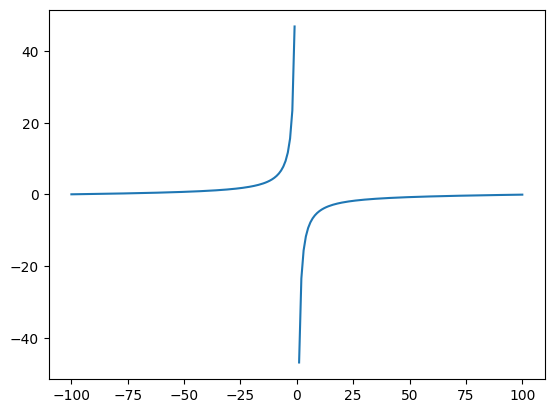

In [29]:
ratio = (E_med1_bZ[:,0] - E_med1_a[:,0])/(E_med1_bZ[:,2] - E_med1_a[:,2])

plt.plot(R_CT,ratio)


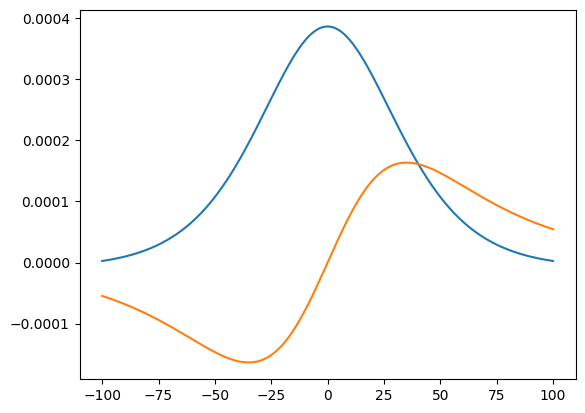

In [31]:
plt.plot(R_CT, abs(E_med1_bZ[:,0] - E_med1_a[:,0]), label='Ez - zmov')
#plt.plot(R_CT, E_med1_bZ[:,1] - E_med1_a[:,1], label='Ey - zmov')
plt.plot(R_CT, E_med1_bZ[:,2] - E_med1_a[:,2], label='Ex - zmov')

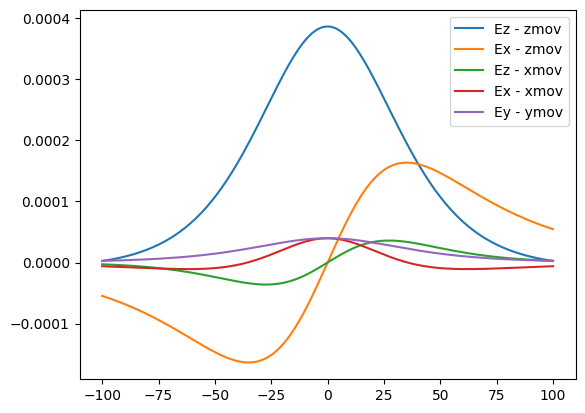

In [18]:
plt.plot(R_CT, abs(E_med1_bZ[:,0] - E_med1_a[:,0]), label='Ez - zmov')
#plt.plot(R_CT, E_med1_bZ[:,1] - E_med1_a[:,1], label='Ey - zmov')
plt.plot(R_CT, E_med1_bZ[:,2] - E_med1_a[:,2], label='Ex - zmov')
plt.plot(R_CT, E_med1_bX[:,0] - E_med1_a[:,0], label='Ez - xmov')
#plt.plot(R_CT, E_med1_bX[:,1] - E_med1_a[:,1], label='y')
plt.plot(R_CT, E_med1_bX[:,2] - E_med1_a[:,2], label='Ex - xmov')
plt.plot(R_CT, E_med1_bY[:,1] - E_med1_a[:,1], label='Ey - ymov')
plt.legend()

In [20]:
np.max(abs(E_med1_bZ[:,0] - E_med1_a[:,0]))

0.00038663986742390813

In [21]:
np.max(abs(E_med1_bZ[:,2] - E_med1_a[:,2]))

0.0001636590367916739

In [22]:
np.max(abs(E_med1_bX[:,2] - E_med1_a[:,2]))

3.983962676145149e-05

In [23]:
np.max(abs(E_med1_bX[:,0] - E_med1_a[:,0]))

3.6035098872642946e-05

In [24]:
np.max(abs(E_med1_bZ[:,0] - E_med1_a[:,0]))/np.max(abs(E_med1_bX[:,2] - E_med1_a[:,2]))

9.704906869208369

In [26]:
np.max(abs(E_med1_bZ[:,2] - E_med1_a[:,2]))/np.max(abs(E_med1_bX[:,0] - E_med1_a[:,0]))

4.541656382575385

In [27]:
np.max(abs(E_med1_bZ[:,0] - E_med1_a[:,0]))/np.max(abs(E_med1_bX[:,0] - E_med1_a[:,0]))

10.729535356358815

In [28]:
np.max(abs(E_med1_bZ[:,2] - E_med1_a[:,2]))/np.max(abs(E_med1_bX[:,2] - E_med1_a[:,2]))

4.107946035027344

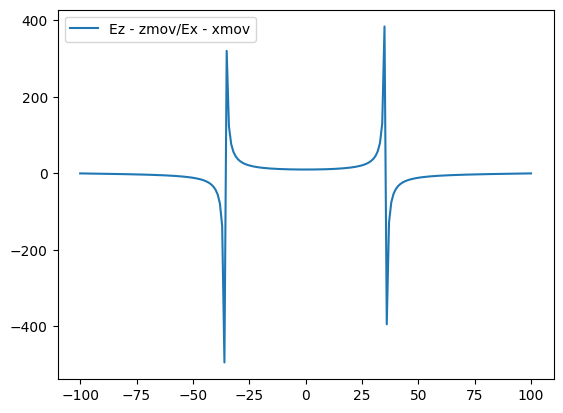

In [19]:
plt.plot(R_CT, abs(E_med1_bZ[:,0] - E_med1_a[:,0])/(E_med1_bX[:,2] - E_med1_a[:,2]), label='Ez - zmov/Ex - xmov')
#plt.plot(R_CT, E_med1_bZ[:,1] - E_med1_a[:,1], label='Ey - zmov')
#plt.plot(R_CT, E_med1_bZ[:,2] - E_med1_a[:,2], label='Ex - zmov')
#plt.plot(R_CT, E_med1_bX[:,0] - E_med1_a[:,0], label='Ez - xmov')
#plt.plot(R_CT, E_med1_bX[:,1] - E_med1_a[:,1], label='y')
#plt.plot(R_CT, E_med1_bX[:,2] - E_med1_a[:,2], label='Ex - xmov')
#plt.plot(R_CT, E_med1_bY[:,1] - E_med1_a[:,1], label='Ey - ymov')
plt.legend()

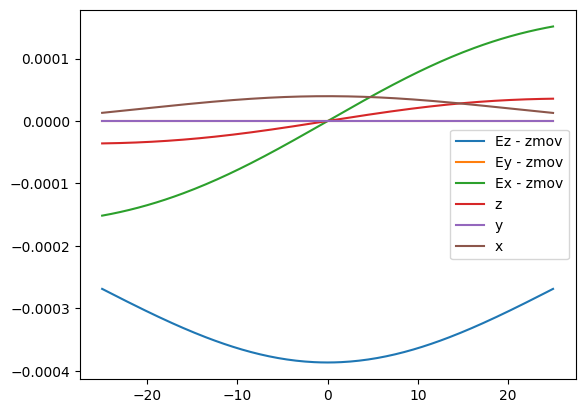

In [7]:
plt.plot(R_CT, E_med1_bZ[:,0] - E_med1_a[:,0], label='Ez - zmov')
plt.plot(R_CT, E_med1_bZ[:,1] - E_med1_a[:,1], label='Ey - zmov')
plt.plot(R_CT, E_med1_bZ[:,2] - E_med1_a[:,2], label='Ex - zmov')
plt.legend()
plt.plot(R_CT, E_med1_bX[:,0] - E_med1_a[:,0], label='z')
plt.plot(R_CT, E_med1_bX[:,1] - E_med1_a[:,1], label='y')
plt.plot(R_CT, E_med1_bX[:,2] - E_med1_a[:,2], label='x')
plt.legend()

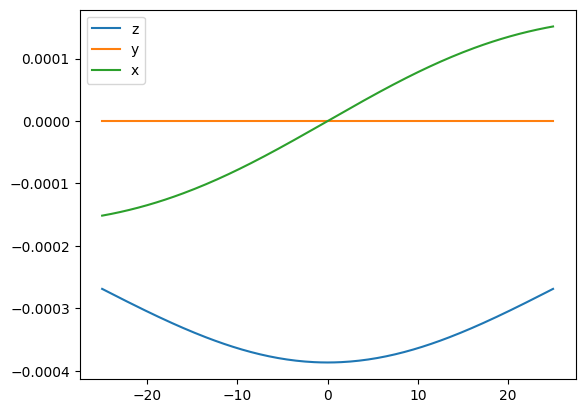

In [16]:
plt.plot(R_CT, E_med1_bZ[:,0] - E_med1_a[:,0], label='z')
plt.plot(R_CT, E_med1_bZ[:,1] - E_med1_a[:,1], label='y')
plt.plot(R_CT, E_med1_bZ[:,2] - E_med1_a[:,2], label='x')
plt.legend()

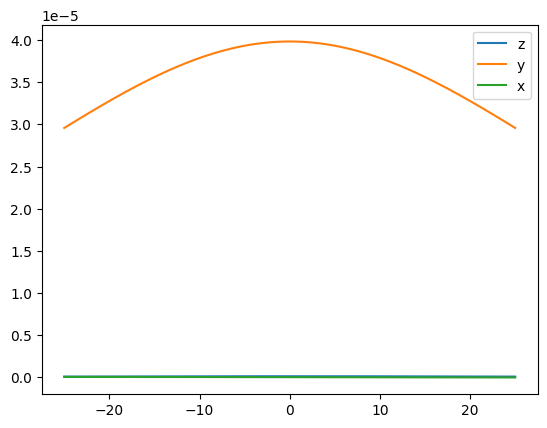

In [17]:
plt.plot(R_CT, E_med1_bY[:,0] - E_med1_a[:,0], label='z')
plt.plot(R_CT, E_med1_bY[:,1] - E_med1_a[:,1], label='y')
plt.plot(R_CT, E_med1_bY[:,2] - E_med1_a[:,2], label='x')
plt.legend()

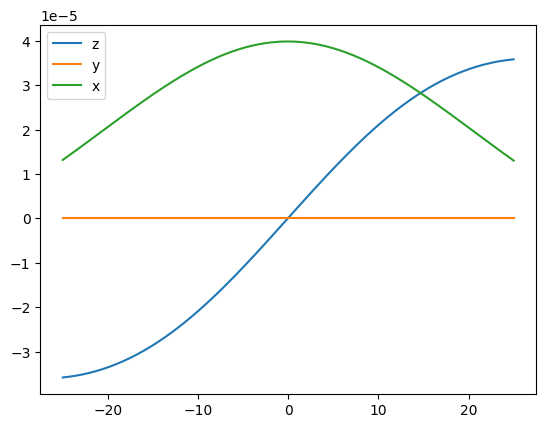

In [18]:
plt.plot(R_CT, E_med1_bX[:,0] - E_med1_a[:,0], label='z')
plt.plot(R_CT, E_med1_bX[:,1] - E_med1_a[:,1], label='y')
plt.plot(R_CT, E_med1_bX[:,2] - E_med1_a[:,2], label='x')
plt.legend()

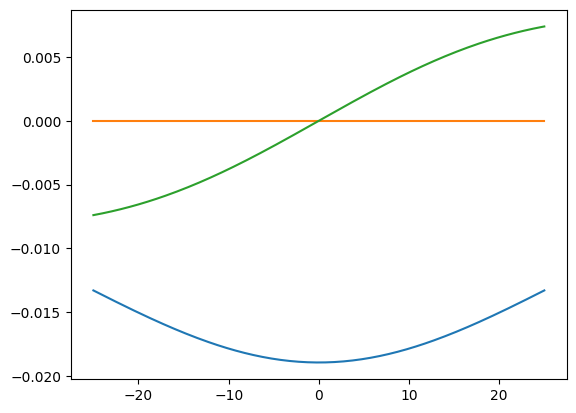

In [5]:
plt.plot(R_CT, E_med1_a)

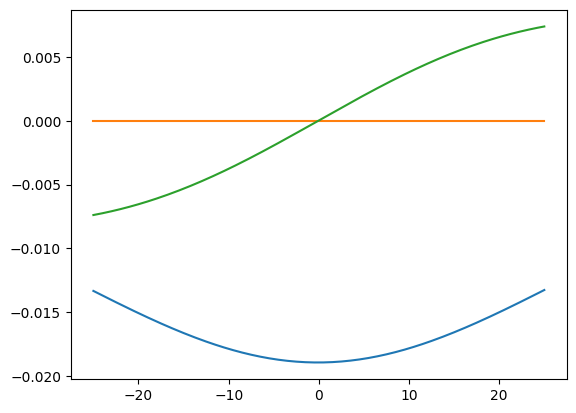

In [6]:
plt.plot(R_CT, E_med1_bX)

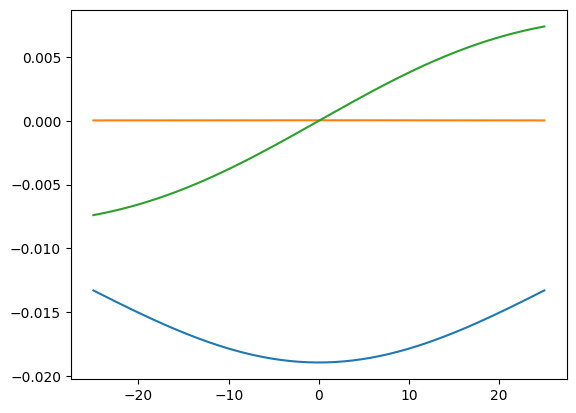

In [7]:
plt.plot(R_CT, E_med1_bY)

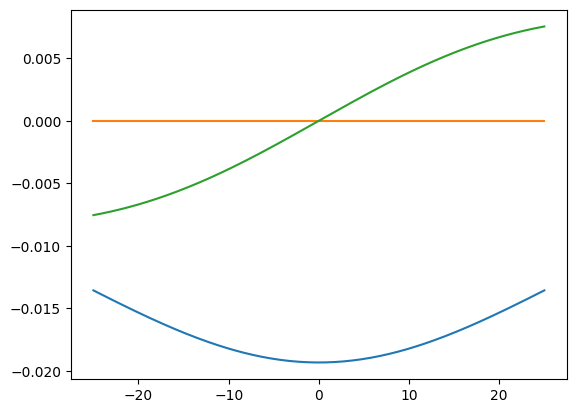

In [8]:
plt.plot(R_CT, E_med1_bZ)